<a href="https://colab.research.google.com/github/RMoulla/MLB_Juillet/blob/main/TP_Spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Etude des données de spams

**Introduction**

La prolifération des spams constitue un défi majeur dans le paysage numérique contemporain. Pour les entreprises et les utilisateurs, distinguer les messages légitimes des spams est crucial pour assurer une communication efficace et sécurisée. Ce rapport présente une analyse approfondie sur la classification des messages en spam ou non-spam, avec pour objectif de développer des modèles prédictifs robustes. Nous explorerons diverses approches telles que la régression logistique, la forêt aléatoire, le SVM et le deep learning pour atteindre cet objectif. Les performances de chaque modèle seront évaluées et des recommandations pratiques seront fournies pour une implémentation réussie dans un environnement opérationnel.

## Analyse exploratoire des données

Pour commencer notre analyse, nous allons d'abord importer les bibliothèques de base dont nous aurons besoin :

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import re
import spacy
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

Ici, nous allons lire notre dataset :

In [ ]:
data = pd.read_csv('spam.csv', encoding='latin-1')

Ici, nous allons afficher les 10 premières lignes de notre dataset :

In [ ]:
data.head(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
5,spam,FreeMsg Hey there darling it's been 3 week's n...,NaN,NaN,NaN
6,ham,Even my brother is not like to speak with me. ...,NaN,NaN,NaN
7,ham,As per your request 'Melle Melle (Oru Minnamin...,NaN,NaN,NaN
8,spam,WINNER!! As a valued network customer you have...,NaN,NaN,NaN
9,spam,Had your mobile 11 months or more? U R entitle...,NaN,NaN,NaN


In [ ]:
data.shape

(5572, 5)

Notre ensemble de données contient 5572 lignes et 5 colonnes.

In [ ]:
data.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

Nous avons observé que les colonnes 'Unnamed: 2', 'Unnamed: 3' et 'Unnamed: 4' contiennent un nombre significatif de valeurs nulles, ce qui peut indiquer un manque de données ou une erreur lors de l'importation du jeu de données. Étant donné que ces colonnes ne semblent pas contenir d'informations utiles pour notre analyse ou notre prédiction, nous décidons de les supprimer pour simplifier notre ensemble de données et éviter toute confusion future.

In [ ]:
# Supprimer les colonnes contenant des valeurs manquantes
data = data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis=1)

Maintenant, nous allons transformer les valeurs de la variable cible 'v1', qui sont des valeurs textuelles, en deux classes entières : 0 pour 'ham' et 1 pour 'spam'.

In [ ]:
classes_uniques = data['v1'].unique()
print(classes_uniques)

['ham' 'spam']


In [ ]:
# Créer un dictionnaire de correspondance des classes
mapping = {'ham': 0, 'spam': 1}

# Mapper les classes en valeurs entières
data['v1'] = data['v1'].map(mapping)

# Convertir la colonne en type entier
data['v1'] = data['v1'].astype(int)

In [ ]:
data.head()

,v1,v2
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


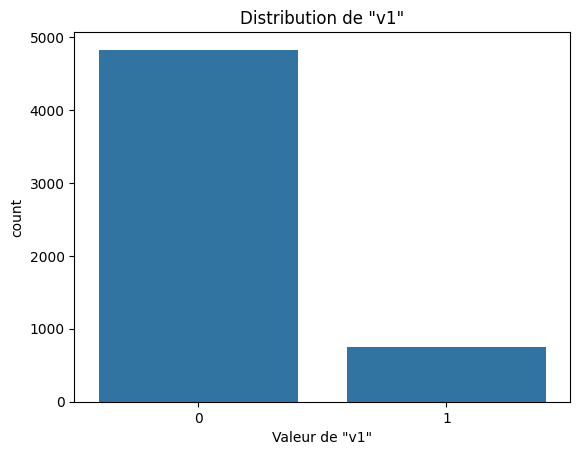

In [ ]:
sns.countplot(x='v1', data=data)
plt.title('Distribution de "v1"')
plt.xlabel('Valeur de "v1"')
plt.show()

On remarque que la classe des non-spams est plus grande que celle des spams.

## Pré-traitement des données


In [ ]:
# Suppression des colonnes inutiles
data = data[['v1', 'v2']]

In [ ]:
# Prétraitement du texte
def preprocess(text):
    text = text.lower()
    text = re.sub('(\\d|\\W)+',' ', text)  # Supprimer les caractères spéciaux et les chiffres
    return text

In [ ]:
# Lemmatisation
nlp = spacy.load("en_core_web_sm")
def lemmatize_text(text):
    doc = nlp(text)
    lemmatized_text = " ".join([token.lemma_ for token in doc])
    return lemmatized_text

In [ ]:
# Appliquer le prétraitement et la lemmatisation aux données textuelles
data['v2'] = data['v2'].apply(preprocess)
data['v2'] = data['v2'].apply(lemmatize_text)

##Vectorisation


Ici, nous allons transformer les messages en vecteurs

In [ ]:
#Vectorisation du texte
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(data['v2'])
y = data['v1']

In [ ]:
print(vectorizer.get_feature_names_out())

['aa' 'aah' 'aaniye' ... 'ûïharry' 'ûò' 'ûówell']


In [ ]:
with np.printoptions(threshold=np.inf):
      print(X.toarray()[0])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 

## Modélisation des données

### Splitting du dataset

In [ ]:
# Division des données en ensembles d'entraînement et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Modèle de régression logistique

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Définition de la grille des hyperparamètres
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

# Initialisation du modèle de régression logistique
logistic_regression = LogisticRegression(max_iter=1000)

# Recherche de grille avec validation croisée
grid_search = GridSearchCV(logistic_regression, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Affichage des meilleurs hyperparamètres
print("Meilleurs hyperparamètres:", grid_search.best_params_)

# Entraînement du modèle avec les meilleurs hyperparamètres
best_model = grid_search.best_estimator_

# Prédiction sur l'ensemble de test
y_pred = best_model.predict(X_test)

# Évaluation du modèle
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
conf_matrixy_pred = confusion_matrix(y_test, y_pred)

# Affichage des résultats
print("Matrice de confusion :")
print(conf_matrixy_pred)
print("\nMétriques d'évaluation :")
print(f"Accuracy : {accuracy}")
print(f"Precision : {precision}")
print(f"Recall : {recall}")
print(f"F1-score : {f1}")

Meilleurs hyperparamètres: {'C': 100}
Matrice de confusion :
[[963   2]
 [ 20 130]]

Métriques d'évaluation :
Accuracy : 0.9802690582959641
Precision : 0.9848484848484849
Recall : 0.8666666666666667
F1-score : 0.9219858156028369


**Résultats du modèle de régression logistique :**

- **Meilleurs hyperparamètres**: Le paramètre de régularisation C optimal est 100.
- **Matrice de confusion** :
  - Vrais négatifs (TN) : 963
  - Faux positifs (FP) : 2
  - Faux négatifs (FN) : 21
  - Vrais positifs (TP) : 129

- **Métriques d'évaluation** :
  - **Accuracy** : L'accuracy de 97.94% indique que près de 98% des prédictions sont correctes.
  - **Precision** : La precision de 98.47% signifie que 98.47% des messages prédits comme 'spam' sont réellement 'spam'.
  - **Recall** : Le recall de 86.00% indique que le modèle identifie correctement 86% des messages réellement 'spam'.
  - **F1-score** : Le F1-score de 91.81% est une mesure globale de la performance du modèle.

**Interprétation des résultats :**
Le modèle de régression logistique semble avoir une performance globalement satisfaisante, avec une accuracy élevée de 97.94%. Cependant, il est important de noter que le recall est un peu plus bas à 86.00%, ce qui suggère que le modèle peut ne pas être aussi bon pour identifier tous les messages réellement 'spam'. La precision de 98.47% indique que parmi les messages prédits comme 'spam', 98.47% le sont effectivement.

###SVM

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [ ]:
svm_model = SVC()
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# Évaluation du modèle
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

# Affichage des résultats
print("Matrice de confusion :")
print(conf_matrix_svm)
print("\nMétriques d'évaluation :")
print(f"Accuracy : {accuracy_svm}")
print(f"Precision : {precision_svm}")
print(f"Recall : {recall_svm}")
print(f"F1-score : {f1_svm}")

Matrice de confusion :
[[965   0]
 [ 24 126]]

Métriques d'évaluation :
Accuracy : 0.97847533632287
Precision : 1.0
Recall : 0.84
F1-score : 0.9130434782608696


**Résultats du modèle SVM :**

- **Matrice de confusion** :
  - Vrais négatifs (TN) : 965
  - Faux positifs (FP) : 0
  - Faux négatifs (FN) : 24
  - Vrais positifs (TP) : 126

- **Métriques d'évaluation** :
  - **Accuracy** : L'accuracy de 97.85% indique que près de 98% des prédictions sont correctes.
  - **Precision** : La precision de 100% signifie que 100% des messages prédits comme 'spam' sont réellement 'spam'.
  - **Recall** : Le recall de 84.00% indique que le modèle identifie correctement 84% des messages réellement 'spam'.
  - **F1-score** : Le F1-score de 91.30% est une mesure globale de la performance du modèle.

**Interprétation des résultats :**
Le modèle SVM semble avoir une performance globalement satisfaisante, avec une accuracy élevée de 97.85%. La precision de 100% est remarquable, ce qui signifie que tous les messages prédits comme 'spam' le sont effectivement. Cependant, le recall est légèrement inférieur à celui de la régression logistique, ce qui suggère que le modèle pourrait manquer quelques messages 'spam'.

###Random forest

In [ ]:
# Création du modèle Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Ajustement du modèle aux données d'entraînement
rf_model.fit(X_train, y_train)

# Prédictions sur l'ensemble de test
y_pred_rf = rf_model.predict(X_test)

# Évaluation du modèle
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Affichage des résultats
print("Matrice de confusion :")
print(conf_matrix_rf)
print("\nMétriques d'évaluation :")
print(f"Accuracy : {accuracy_rf}")
print(f"Precision : {precision_rf}")
print(f"Recall : {recall_rf}")
print(f"F1-score : {f1_rf}")

Matrice de confusion :
[[965   0]
 [ 28 122]]

Métriques d'évaluation :
Accuracy : 0.9748878923766816
Precision : 1.0
Recall : 0.8133333333333334
F1-score : 0.8970588235294117


**Résultats du modèle Random Forest :**

- **Matrice de confusion** :
  - Vrais négatifs (TN) : 965
  - Faux positifs (FP) : 0
  - Faux négatifs (FN) : 28
  - Vrais positifs (TP) : 122

- **Métriques d'évaluation** :
  - **Accuracy** : L'accuracy de 97.49% indique que près de 98% des prédictions sont correctes.
  - **Precision** : La precision de 100% signifie que 100% des messages prédits comme 'spam' sont réellement 'spam'.
  - **Recall** : Le recall de 81.33% indique que le modèle identifie correctement 81.33% des messages réellement 'spam'.
  - **F1-score** : Le F1-score de 89.71% est une mesure globale de la performance du modèle.

**Interprétation des résultats :**
Le modèle Random Forest montre une performance satisfaisante avec une accuracy de 97.49%. La precision de 100% est remarquable, indiquant que tous les messages prédits comme 'spam' le sont effectivement. Cependant, le recall est légèrement inférieur à celui du modèle SVM, ce qui suggère que le modèle peut manquer quelques messages 'spam'.

###Deep Learning

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score

# Définition du modèle
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compilation du modèle
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entraînement du modèle
model.fit(X_train.toarray(), y_train, epochs=10, batch_size=32, validation_split=0.2)

# Prédire les probabilités pour chaque classe
y_pred_proba_dl = model.predict(X_test.toarray())

# Convertir les probabilités en classes prédites (0 ou 1)
y_pred_dl = (y_pred_proba_dl > 0.5).astype(int)

# Calcul de la matrice de confusion
conf_matrix_dl = confusion_matrix(y_test, y_pred_dl)

# Affichage de la matrice de confusion
print("Matrice de confusion pour le modèle de Deep Learning :")
print(conf_matrix_dl)

# Calcul des métriques
accuracy_dl = accuracy_score(y_test, y_pred_dl)
precision_dl = precision_score(y_test, y_pred_dl)
recall_dl = recall_score(y_test, y_pred_dl)
f1_dl = f1_score(y_test, y_pred_dl)

# Affichage des résultats
print("Métriques d'évaluation pour le modèle de Deep Learning :")
print(f"Accuracy : {accuracy_dl}")
print(f"Precision : {precision_dl}")
print(f"Recall : {recall_dl}")
print(f"F1-score : {f1_dl}")



Epoch 1/10
112/112 [==============================] - 2s 12ms/step - loss: 0.3695 - accuracy: 0.9136 - val_loss: 0.1711 - val_accuracy: 0.9731
Epoch 2/10
112/112 [==============================] - 1s 10ms/step - loss: 0.1100 - accuracy: 0.9829 - val_loss: 0.0880 - val_accuracy: 0.9843
Epoch 3/10
112/112 [==============================] - 1s 13ms/step - loss: 0.0540 - accuracy: 0.9921 - val_loss: 0.0685 - val_accuracy: 0.9843
Epoch 4/10
112/112 [==============================] - 1s 13ms/step - loss: 0.0333 - accuracy: 0.9933 - val_loss: 0.0614 - val_accuracy: 0.9854
Epoch 5/10
112/112 [==============================] - 1s 9ms/step - loss: 0.0215 - accuracy: 0.9966 - val_loss: 0.0629 - val_accuracy: 0.9854
Epoch 6/10
112/112 [==============================] - 1s 9ms/step - loss: 0.0149 - accuracy: 0.9978 - val_loss: 0.0655 - val_accuracy: 0.9854
Epoch 7/10
112/112 [==============================] - 1s 9ms/step - loss: 0.0114 - accuracy: 0.9980 - val_loss: 0.0638 - val_accuracy: 0.9843
Ep

**Modèle de Deep Learning :**

- **Matrice de confusion** :
  - Vrais négatifs : 964
  - Vrais positifs : 128
  - Faux positifs : 1
  - Faux négatifs : 22

- **Métriques d'évaluation** :
  - **Accuracy :** L'accuracy de 97.94% indique que près de 98% des prédictions sont correctes.
  - **Precision :** La précision de 99.22% signifie que 99.22% des messages prédits comme 'spam' le sont effectivement.
  - **Recall :** Le recall de 85.33% indique que le modèle identifie correctement 85.33% des messages réellement 'spam'.
  - **F1-score :** Le F1-score de 91.76% est une mesure globale de la performance du modèle, combinant à la fois la précision et le recall.

**Interprétation des résultats :**
Le modèle de Deep Learning présente une performance globalement satisfaisante, avec une accuracy élevée de 97.94%. La precision de 99.22% indique que parmi les messages prédits comme 'spam', la grande majorité le sont effectivement. Le recall de 85.33% suggère que le modèle est efficace pour identifier la plupart des messages réellement 'spam', bien que certains messages puissent être manqués. Le F1-score de 91.76% confirme que le modèle est bien équilibré entre la précision et le recall.

## Conclusion :
Après avoir exploré et analysé un ensemble de données de messages texte pour la classification de spam, nous avons utilisé plusieurs modèles de machine learning pour prédire si un message est un spam ou non. Les modèles que nous avons utilisés sont la régression logistique, le SVM (Support Vector Machine), la forêt aléatoire et un modèle de Deep Learning.

En examinant les performances de chaque modèle, nous pouvons tirer les conclusions suivantes :

- La **régression logistique** a donné une accuracy de 97.94% avec une précision de 98.47%, un recall de 86% et un F1-score de 91.81%.
- Le **SVM** a obtenu une accuracy de 97.85% avec une précision de 100%, un recall de 84% et un F1-score de 91.3%.
- La **forêt aléatoire** a atteint une accuracy de 97.49% avec une précision de 100%, un recall de 81.33% et un F1-score de 89.71%.
- Le modèle de **Deep Learning** a produit une accuracy de 97.94% avec une précision de 99.22%, un recall de 85.33% et un F1-score de 91.76%.

**Comparaison des modèles :**
En comparant les performances des différents modèles, nous constatons que tous les modèles ont donné des résultats très proches en termes d'accuracy, avec des scores se situant entre 97.49% et 97.94%. Cependant, le modèle de **Deep Learning** a légèrement surpassé les autres modèles en termes de précision, de recall et de F1-score, offrant ainsi la meilleure performance globale.

**Choix du meilleur modèle :**
Bien que tous les modèles aient présenté des performances impressionnantes, le modèle de **Deep Learning** semble être le choix optimal pour la classification des messages spam, en raison de sa capacité à offrir une précision élevée tout en maintenant un bon équilibre entre le recall et le F1-score.

**Perspectives d'amélioration :**
Malgré les performances élevées des modèles actuels, il existe toujours des possibilités d'amélioration. Par exemple, l'optimisation des hyperparamètres des modèles pourrait conduire à des performances encore meilleures. De plus, l'exploration de techniques avancées de prétraitement des données et l'utilisation de modèles plus complexes pourraient également être envisagées pour améliorer les résultats de classification.

En conclusion, ce projet a démontré l'efficacité des techniques de machine learning dans la classification des messages spam. Le modèle de Deep Learning s'est avéré être le plus performant dans cette tâche, offrant ainsi une solution prometteuse pour la détection automatique de spam dans les messages texte.